<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# K Vizinhos mais Próximos (K-Nearest Neighbors)


O KNN é um algoritmo baseado em similaridade. Ou seja, para prever uma saída o algoritmo procura, no conjunto de treinamento, os $k$ vizinhos (exemplos) mais próximos do valor de entrada.

Por esta característica de depender dos dados de treinamento a todo o momento que vai fazer uma predição, O KNN é um algoritmo considerado preguiçoso (lazy).

## Classificação

Para fazer a classificação o KNN verifica a similaridade, ou a distância do ponto que se quer fazer a predição, e então define a classe por votação.


## Regressão

Na regressão o valor da predição é calculado com base na médias dos valores dos vizinhos mais próximos.

## Como são Calculadas as Distâncias no KNN

Duas amostras são consideradas próximas quando a distância entre elas for pequena. Por exemplo, considerando as amostras $A$ e $B$:

$$
A = (x_1, y_1)
$$

$$
B = (x_2, y_2)
$$

A distância euclidiana entre elas é:

$$
d(A,B) = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
$$

Fórmula generalizadas para o cálculo das distâncias para $m$ atributos:

$$
d(A,B) = \sqrt{\sum_{j=1}^{m}(x_j-z_j)^2}
$$

onde $m$ é o número de atributos.


Além da distância Euclidiana, o KNN pode usar também:

### Distância Manhattan

$$
d(x,z)=\sum_{j=1}^{m}|x_j-z_j|
$$

### Distância de Minkowski

$$
d(x,z)=\left(\sum_{j=1}^{m}|x_j-z_j|^p\right)^{1/p}
$$

Neste caso, quando:

- $p=1$: Manhattan;
- $p=2$: Euclidiana.

## Passos do algoritmo KNN

Considerando a amostra $x_{novo}$, os seguintes passos são executados:

1. calcular a distância entre $x_{novo}$ e todas as amostras do conjunto de treinamento;
2. ordenar as amostras da menor para a maior distância;
3. selecionar os $k$ vizinhos mais próximos;
4. fazer a predição:
   - classificação: classe mais frequente entre os vizinhos;
   - regressão: média ou média ponderada dos valores dos vizinhos.

O parâmetro $k$ controla quantos vizinhos serão considerados.

# Exemplo do KNN com dados aleatórios

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
X, y = make_classification(
    n_samples=120,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel('Atributo 1 (X_0)')
plt.ylabel('Atributo 2 (x_1)')
plt.title('Conjunto de dados para classificação')
plt.grid(True)
plt.show()

### Classificação Manual (sem uso de biblioteca)

In [3]:
# Nova amostra a ser classificada
novo_ponto = np.array([[0.5, 1.0]])

# Cálculo das distâncias euclidianas
distancias = np.sqrt(np.sum((X - novo_ponto)**2, axis=1))

# Índices dos 5 vizinhos mais próximos
k = 5
indices_vizinhos = np.argsort(distancias)[:k]

print('Índices dos vizinhos mais próximos..:', indices_vizinhos)
print('Classes dos vizinhos................:', y[indices_vizinhos])
print('Distâncias..........................:', distancias[indices_vizinhos])

Índices dos vizinhos mais próximos..: [62  1 57 87 34]
Classes dos vizinhos................: [1 1 1 1 1]
Distâncias..........................: [0.13169377 0.16935275 0.38884918 0.41028775 0.42303033]


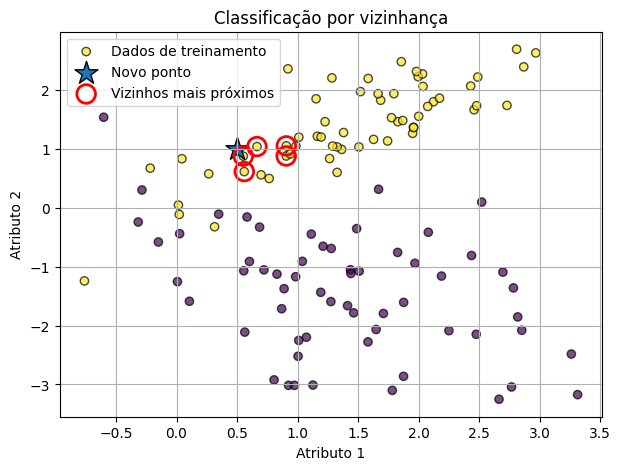

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', alpha=0.7, label='Dados de treinamento')
plt.scatter(novo_ponto[:, 0], novo_ponto[:, 1], marker='*', s=300, edgecolor='k', label='Novo ponto')
plt.scatter(X[indices_vizinhos, 0], X[indices_vizinhos, 1], s=180, facecolors='none', edgecolor='red', linewidth=2, label='Vizinhos mais próximos')
plt.xlabel('Atributo 1')
plt.ylabel('Atributo 2')
plt.title('Classificação por vizinhança')
plt.legend()
plt.grid(True)
plt.show()

### Classificação com o uso da bibiblioteca scikit-learn

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(novo_ponto)

print(y_pred)

[1]


### Regressão com o uso da biblioteca scikit-learning

In [10]:
from sklearn.datasets import make_regression

In [13]:
X, y = make_regression(n_samples=100,
                       n_features=1,
                       noise=15,
                       random_state=42)

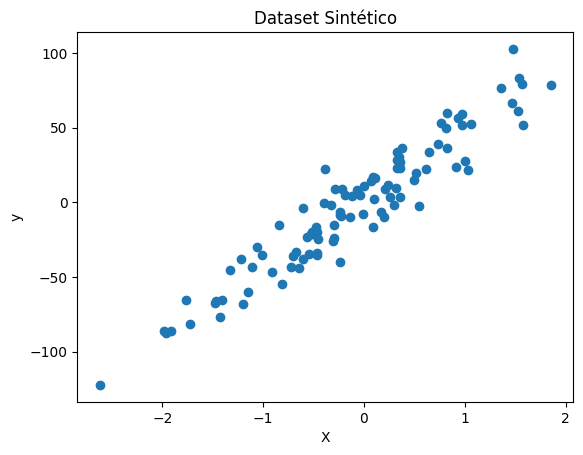

In [14]:
plt.scatter(X, y)
plt.title("Dataset Sintético")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [15]:
from sklearn.neighbors import KNeighborsRegressor

# Modelo
knn_r = KNeighborsRegressor(n_neighbors=5)

# Treino
knn_r.fit(X, y)

KNeighborsRegressor()

In [16]:
# Criar pontos para desenhar a curva
X_test = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# Predição
y_pred = knn_r.predict(X_test)

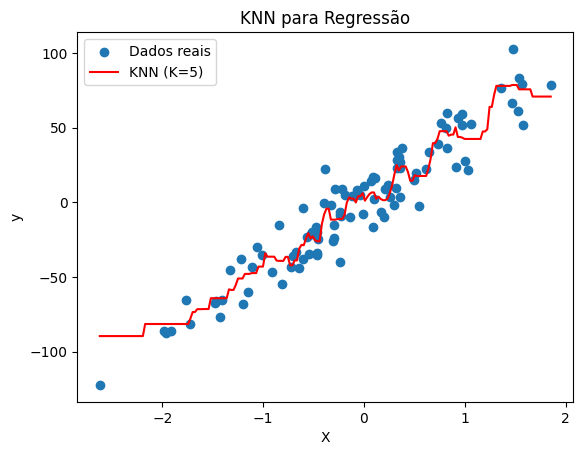

In [17]:
plt.scatter(X, y, label="Dados reais")
plt.plot(X_test, y_pred, color='red', label="KNN (K=5)")
plt.title("KNN para Regressão")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [19]:
novo_ponto = np.array([[0.5]])

y_pred = knn_r.predict(novo_ponto)

print(y_pred)

[18.11934552]


## Definição do Parâmetro K

O parâmetro $k$ é fundamental no algoritmo KNN. Um $k$ muito pequeno pode fazer com que o modelo fique sensível a ruídos. Já um $k$ muito grande pode fazer com que o modelo fique mais estável, mas pode gerar underfitting.

Um dos métodos utilizados para definir o valor do parâmetro $k$ é o de validação cruzada que basicamente visa testar diferentes valores de $k$ e escolher aquele que gerou o melhor desempenho médio.

Outra maneira de definir o $k$ é de form heurística. Neste caso, calcula-se o $k$ da seguinte maneira:

$$
K \approx \sqrt{N}
$$

Onde $N$ representa o número de amostras.

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.